Full: (2000, 3)
Train: (1379, 3)
Test: (296, 3)


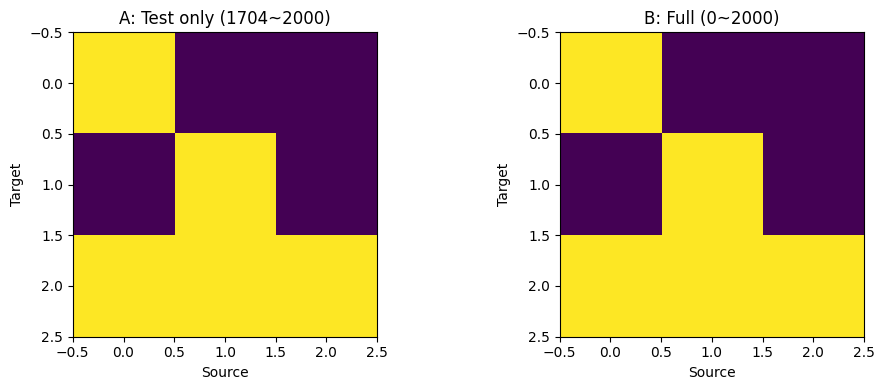


=== GC (Test only) ===
[[1 0 0]
 [0 1 0]
 [1 1 1]]

=== GC (Full) ===
[[1 0 0]
 [0 1 0]
 [1 1 1]]


In [7]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import h5py

from models.cmlp import cMLP, train_model_ista

# ===============================
# 1. 데이터 로드 (첫번째 simulation만)
# ===============================
h5_path = "simulated/260420_data/three_nodes/signal.h5"

with h5py.File(h5_path, "r") as f:
    X_np = f["signal"][()].astype(np.float32)

# (simulation, feature, timestep) → (simulation, timestep, feature)
X_np = X_np.transpose(0, 2, 1)

# 첫 번째 simulation만 사용
X_full = X_np[0]  # (2000, 3)

# split
train_X = X_full[:1379]
test_X  = X_full[1704:2000]

print("Full:", X_full.shape)
print("Train:", train_X.shape)
print("Test:", test_X.shape)

# ===============================
# 2. 공통 함수
# ===============================
def run_cmlp(X_np, lag=1):
    X = torch.tensor(X_np, dtype=torch.float32).unsqueeze(0)

    p = X.shape[-1]

    model = cMLP(
        num_series=p,
        lag=lag,
        hidden=[100],
        activation='relu'
    )

    train_model_ista(
        model,
        X,
        lam=1,
        lr=1e-2,
        max_iter=2000,
        check_every=100,
        verbose=0
    )

    GC = model.GC().detach().cpu().numpy()
    return GC


# ===============================
# 3. A 방식 (test만)
# ===============================
GC_test_only = run_cmlp(test_X, lag=1)

# ===============================
# 4. B 방식 (전체 사용)
# ===============================
GC_full = run_cmlp(X_full, lag=1)

# ===============================
# 5. 시각화
# ===============================
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(GC_test_only, cmap="viridis")
axes[0].set_title("A: Test only (1704~2000)")
axes[0].set_xlabel("Source")
axes[0].set_ylabel("Target")

axes[1].imshow(GC_full, cmap="viridis")
axes[1].set_title("B: Full (0~2000)")
axes[1].set_xlabel("Source")
axes[1].set_ylabel("Target")

plt.tight_layout()
plt.show()

# ===============================
# 6. 수치 출력
# ===============================
print("\n=== GC (Test only) ===")
print(GC_test_only)

print("\n=== GC (Full) ===")
print(GC_full)

Full: (2000, 3)
Train: (1379, 3)
Test: (296, 3)


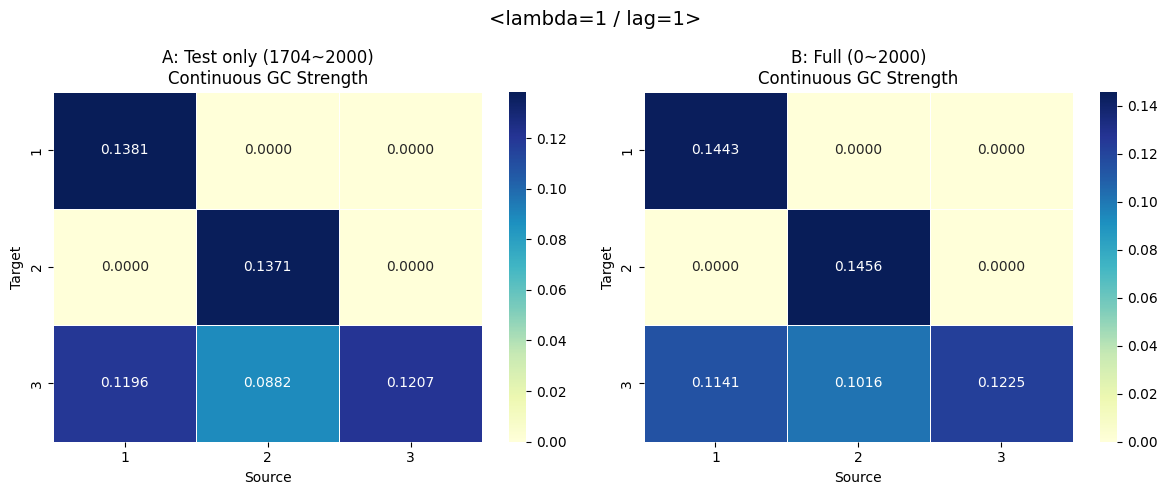


=== A: Binary GC (Test only) ===
[[1 0 0]
 [0 1 0]
 [1 1 1]]

=== A: Continuous GC Strength (Test only) ===
[[0.1381 0.     0.    ]
 [0.     0.1371 0.    ]
 [0.1196 0.0882 0.1207]]

=== B: Binary GC (Full) ===
[[1 0 0]
 [0 1 0]
 [1 1 1]]

=== B: Continuous GC Strength (Full) ===
[[0.1443 0.     0.    ]
 [0.     0.1456 0.    ]
 [0.1141 0.1016 0.1225]]


In [6]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import h5py

from models.cmlp import cMLP, train_model_ista


# ===============================
# 1. 데이터 로드
# ===============================
h5_path = "simulated/260420_data/three_nodes/signal.h5"

with h5py.File(h5_path, "r") as f:
    X_np = f["signal"][()].astype(np.float32)

# (simulation, feature, timestep) -> (simulation, timestep, feature)
X_np = X_np.transpose(0, 2, 1)

# 첫 번째 simulation만 사용
X_full = X_np[0]  # (2000, 3)

train_X = X_full[:1379]
test_X = X_full[1704:2000]

print("Full:", X_full.shape)
print("Train:", train_X.shape)
print("Test:", test_X.shape)


# ===============================
# 2. Continuous GC strength 추출 함수
# ===============================
def extract_gc_strength(cmlp):
    """
    cMLP 내부 각 output network의 첫 Conv1d weight norm을 사용해
    continuous GC strength matrix를 추출.
    
    return shape: (target, source)
    """

    strengths = []

    for net in cmlp.networks:
        first_conv = None

        for module in net.modules():
            if isinstance(module, torch.nn.Conv1d):
                first_conv = module
                break

        if first_conv is None:
            raise RuntimeError("Conv1d layer를 찾지 못했습니다.")

        # weight shape은 구현에 따라 다를 수 있지만,
        # Neural-GC cMLP에서는 보통 input series별 weight norm을 계산
        w = first_conv.weight.detach().cpu()

        # source별 norm
        s = torch.norm(w, dim=(0, 2))
        strengths.append(s.numpy())

    strengths = np.stack(strengths, axis=0)
    return strengths


# ===============================
# 3. 공통 실행 함수
# ===============================
def run_cmlp_strength(X_np, lag=1, lam=1.0):
    X = torch.tensor(X_np, dtype=torch.float32).unsqueeze(0)

    p = X.shape[-1]

    model = cMLP(
        num_series=p,
        lag=lag,
        hidden=[100],
        activation="relu"
    )

    train_model_ista(
        model,
        X,
        lam=lam,
        lr=1e-2,
        max_iter=2000,
        check_every=100,
        verbose=0
    )

    # Binary도 같이 확인용으로 뽑기
    GC_binary = model.GC().detach().cpu().numpy()

    # Continuous strength
    GC_strength = extract_gc_strength(model)

    return GC_binary, GC_strength


# ===============================
# 4. A/B 방식 실행
# ===============================
lag = 1
lam = 1

GC_test_binary, GC_test_strength = run_cmlp_strength(test_X, lag=lag, lam=lam)
GC_full_binary, GC_full_strength = run_cmlp_strength(X_full, lag=lag, lam=lam)


# ===============================
# 5. 시각화: continuous strength
# ===============================
plt.figure(figsize=(12, 5))

plt.suptitle(f"<lambda={lam} / lag={lag}>", fontsize=14)

plt.subplot(1, 2, 1)
sns.heatmap(
    GC_test_strength,
    annot=True,
    cmap="YlGnBu",
    fmt=".4f",
    linewidths=0.5,
    xticklabels=[1, 2, 3],
    yticklabels=[1, 2, 3]
)
plt.title("A: Test only (1704~2000)\nContinuous GC Strength")
plt.xlabel("Source")
plt.ylabel("Target")

plt.subplot(1, 2, 2)
sns.heatmap(
    GC_full_strength,
    annot=True,
    cmap="YlGnBu",
    fmt=".4f",
    linewidths=0.5,
    xticklabels=[1, 2, 3],
    yticklabels=[1, 2, 3]
)
plt.title("B: Full (0~2000)\nContinuous GC Strength")
plt.xlabel("Source")
plt.ylabel("Target")

plt.tight_layout()
plt.show()


# ===============================
# 6. 출력
# ===============================
print("\n=== A: Binary GC (Test only) ===")
print(GC_test_binary)

print("\n=== A: Continuous GC Strength (Test only) ===")
print(np.round(GC_test_strength, 4))

print("\n=== B: Binary GC (Full) ===")
print(GC_full_binary)

print("\n=== B: Continuous GC Strength (Full) ===")
print(np.round(GC_full_strength, 4))